# Feature Engineering Review

This notebook reviews the engineered features used by the model.

The model does not use team names as direct training features. It uses match-level signals such as:

```text
Elo strength
recent form
goals for and against
opponent quality
rest proxy
host and neutral flags
match importance
```

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data" / "processed"

training = pd.read_csv(DATA_DIR / "match_training_data.csv")
teams = pd.read_csv(DATA_DIR / "wc2026_teams_model_input.csv")
team_features = pd.read_csv(DATA_DIR / "team_form_elo_latest.csv")

training.head()

,match_id,match_date,team_a_raw_name,team_b_raw_name,team_a_id,team_b_id,team_a_is_wc2026,team_b_is_wc2026,tournament,neutral_flag,...,team_b_days_since_last_match,wins_last_5_difference,points_avg_last_5_difference,goal_diff_avg_last_5_difference,goals_for_avg_last_10_difference,goals_against_avg_last_10_difference,goal_diff_avg_last_10_difference,avg_opponent_elo_last_10_difference,days_since_last_match_difference,match_date_dt
0,HIST_000000,2014-01-01,Kuwait,Jordan,Kuwait,JOR,0,1,WAFF Championship,1.0,...,365.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,2014-01-01
1,HIST_000001,2014-01-04,Bahrain,Jordan,Bahrain,JOR,0,1,WAFF Championship,1.0,...,3.0,-1.0,-3.0,-1.0,-2.0,-1.0,-1.0,0.000000,362.0,2014-01-04
2,HIST_000002,2014-01-04,Namibia,Ghana,Namibia,GHA,0,1,Friendly,0.0,...,365.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,2014-01-04
3,HIST_000003,2014-01-04,Qatar,Kuwait,QAT,Kuwait,1,0,WAFF Championship,0.0,...,3.0,0.0,0.0,1.0,-1.0,-2.0,1.0,0.000000,362.0,2014-01-04
4,HIST_000004,2014-01-07,Qatar,Jordan,QAT,JOR,1,1,WAFF Championship,0.0,...,3.0,-1.0,0.0,2.0,1.5,-0.5,2.0,-16.931472,0.0,2014-01-07


In [2]:
strength_features = [
    "team_a_pre_elo",
    "team_b_pre_elo",
    "pre_elo_difference",
    "team_a_avg_opponent_elo_last_10",
    "team_b_avg_opponent_elo_last_10",
    "avg_opponent_elo_last_10_difference",
]

form_features = [
    "team_a_matches_last_5",
    "team_b_matches_last_5",
    "team_a_wins_last_5",
    "team_b_wins_last_5",
    "wins_last_5_difference",
    "team_a_points_avg_last_5",
    "team_b_points_avg_last_5",
    "points_avg_last_5_difference",
    "team_a_goal_diff_avg_last_5",
    "team_b_goal_diff_avg_last_5",
    "goal_diff_avg_last_5_difference",
]

attack_defense_features = [
    "team_a_goals_for_avg_last_10",
    "team_b_goals_for_avg_last_10",
    "goals_for_avg_last_10_difference",
    "team_a_goals_against_avg_last_10",
    "team_b_goals_against_avg_last_10",
    "goals_against_avg_last_10_difference",
    "team_a_goal_diff_avg_last_10",
    "team_b_goal_diff_avg_last_10",
    "goal_diff_avg_last_10_difference",
    "team_a_pre_elo",
    "team_b_pre_elo",
    "pre_elo_difference",
    "team_a_host_advantage",
    "team_b_host_advantage",
    "neutral_flag",
]

context_features = [
    "neutral_flag",
    "importance",
    "team_a_host_advantage",
    "team_b_host_advantage",
    "team_a_days_since_last_match",
    "team_b_days_since_last_match",
    "days_since_last_match_difference",
]

draw_features = [
    "pre_elo_difference",
    "team_a_points_avg_last_5",
    "team_b_points_avg_last_5",
    "points_avg_last_5_difference",
    "team_a_goal_diff_avg_last_10",
    "team_b_goal_diff_avg_last_10",
    "goal_diff_avg_last_10_difference",
    "team_a_goals_for_avg_last_10",
    "team_b_goals_for_avg_last_10",
    "team_a_goals_against_avg_last_10",
    "team_b_goals_against_avg_last_10",
    "neutral_flag",
    "importance",
]

feature_groups = {
    "strength_features": strength_features,
    "form_features": form_features,
    "attack_defense_features": attack_defense_features,
    "context_features": context_features,
    "draw_features": draw_features,
}

pd.DataFrame([
    {"group": group, "feature_count": len(features)}
    for group, features in feature_groups.items()
])

,group,feature_count
0,strength_features,6
1,form_features,11
2,attack_defense_features,15
3,context_features,7
4,draw_features,13


In [3]:
# Check whether all planned features exist in the training data.
rows = []

for group, features in feature_groups.items():
    for feature in features:
        rows.append({
            "group": group,
            "feature": feature,
            "exists": feature in training.columns,
            "missing_count": training[feature].isna().sum() if feature in training.columns else None,
        })

feature_check = pd.DataFrame(rows)
feature_check

,group,feature,exists,missing_count
0,strength_features,team_a_pre_elo,True,0
1,strength_features,team_b_pre_elo,True,0
2,strength_features,pre_elo_difference,True,0
3,strength_features,team_a_avg_opponent_elo_last_10,True,0
4,strength_features,team_b_avg_opponent_elo_last_10,True,0
5,strength_features,avg_opponent_elo_last_10_difference,True,0
6,form_features,team_a_matches_last_5,True,0
7,form_features,team_b_matches_last_5,True,0
8,form_features,team_a_wins_last_5,True,0
9,form_features,team_b_wins_last_5,True,0


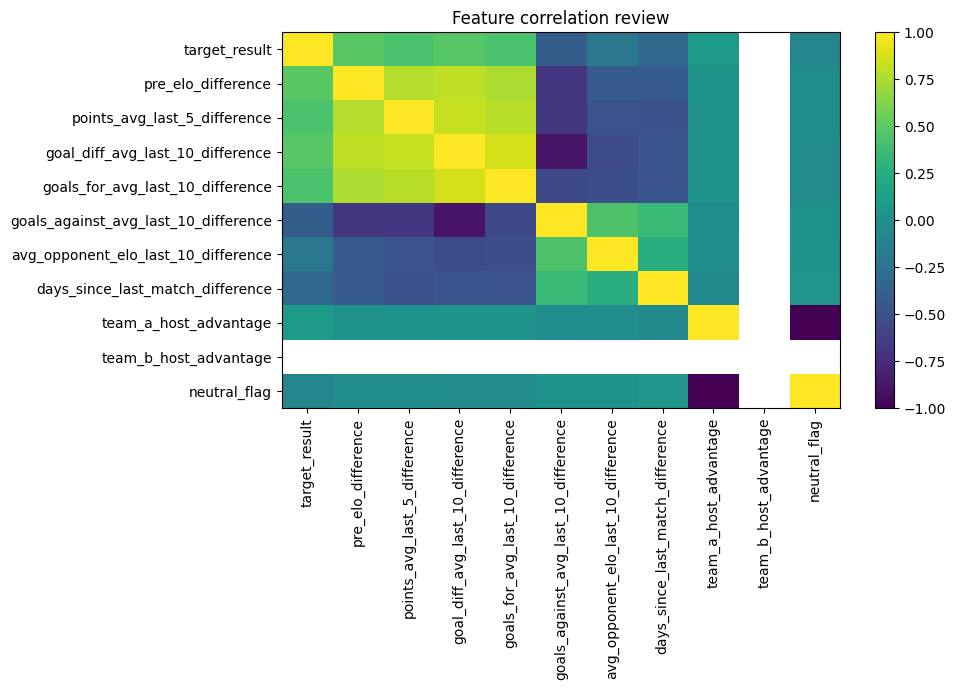

target_result                           1.000000
pre_elo_difference                      0.489559
goal_diff_avg_last_10_difference        0.477126
points_avg_last_5_difference            0.434862
goals_for_avg_last_10_difference        0.431052
team_a_host_advantage                   0.093253
neutral_flag                           -0.093253
avg_opponent_elo_last_10_difference    -0.203649
days_since_last_match_difference       -0.314900
goals_against_avg_last_10_difference   -0.411694
team_b_host_advantage                        NaN
Name: target_result, dtype: float64

In [4]:
# Correlation review for selected numeric features and target.
selected = [
    "target_result",
    "pre_elo_difference",
    "points_avg_last_5_difference",
    "goal_diff_avg_last_10_difference",
    "goals_for_avg_last_10_difference",
    "goals_against_avg_last_10_difference",
    "avg_opponent_elo_last_10_difference",
    "days_since_last_match_difference",
    "team_a_host_advantage",
    "team_b_host_advantage",
    "neutral_flag",
]

corr = training[selected].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Feature correlation review")
plt.tight_layout()
plt.show()

corr["target_result"].sort_values(ascending=False)

In [5]:
# Latest team features used at prediction time
team_snapshot = teams.merge(
    team_features,
    on=["team_id", "team_name"],
    how="left",
    suffixes=("", "_feature")
)

team_snapshot.sort_values("current_elo", ascending=False).head(15)

,team_id,fifa_code,team_name,common_name,group_code,group_slot,confederation,is_host,host_country,fifa_rank,...,points_avg_last_5,goal_diff_avg_last_5,matches_last_10,wins_last_10,points_avg_last_10,goals_for_avg_last_10,goals_against_avg_last_10,goal_diff_avg_last_10,avg_opponent_elo_last_10,days_since_last_match
28,ESP,ESP,Spain,Spain,H,1,UEFA,0,NaN,2,...,1.8,1.0,10,7,2.4,2.8,0.4,2.4,1602.426360,3
32,FRA,FRA,France,France,I,1,UEFA,0,NaN,3,...,2.4,1.2,10,8,2.5,2.5,0.9,1.6,1587.131309,3
36,ARG,ARG,Argentina,Argentina,J,1,CONMEBOL,0,NaN,1,...,3.0,2.6,10,8,2.5,2.5,0.3,2.2,1560.081657,2
44,ENG,ENG,England,England,L,1,UEFA,0,NaN,4,...,2.0,1.0,10,8,2.5,2.4,0.2,2.2,1586.693283,1
9,MAR,MAR,Morocco,Morocco,C,2,CAF,0,NaN,7,...,2.2,2.0,10,7,2.4,2.2,0.3,1.9,1614.595183,4
21,JPN,JPN,Japan,Japan,F,2,AFC,0,NaN,18,...,3.0,1.6,10,7,2.3,1.9,0.6,1.3,1673.619950,11
20,NED,NED,Netherlands,Netherlands,F,1,UEFA,0,NaN,8,...,2.0,1.0,10,6,2.1,2.2,0.8,1.4,1569.458330,3
40,POR,POR,Portugal,Portugal,K,1,UEFA,0,NaN,5,...,2.6,2.4,10,7,2.3,2.6,0.9,1.7,1573.065149,1
8,BRA,BRA,Brazil,Brazil,C,1,CONMEBOL,0,NaN,6,...,2.0,1.2,10,6,1.9,2.5,1.1,1.4,1749.471879,5
16,GER,GER,Germany,Germany,E,1,UEFA,0,NaN,10,...,3.0,2.6,10,9,2.7,2.8,0.8,2.0,1531.092360,5
